In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("forestfires.csv")

print("Розмір початкового набору:", df.shape)
display(df.head())

Розмір початкового набору: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [3]:
duplicate_count = df.duplicated().sum()

print("Кількість повних дублікатів:", duplicate_count)

df_clean = df.drop_duplicates().reset_index(drop=True)

print("Розмір після видалення дублікатів:", df_clean.shape)

Кількість повних дублікатів: 4
Розмір після видалення дублікатів: (513, 13)


In [4]:
target = "area"

numeric_features = [
    "X",
    "Y",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]

categorical_features = [
    "month",
    "day"
]

X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Кількість об'єктів:", len(df_clean))
print("Кількість вхідних ознак:", X.shape[1])
print("Цільова змінна:", target)

Кількість об'єктів: 513
Кількість вхідних ознак: 12
Цільова змінна: area


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Розмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)

print("Кількість значень y_train:", len(y_train))
print("Кількість значень y_test:", len(y_test))

Розмір навчальної вибірки: (410, 12)
Розмір тестової вибірки: (103, 12)
Кількість значень y_train: 410
Кількість значень y_test: 103


In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Розмір X_train після preprocessing:", X_train_processed.shape)
print("Розмір X_test після preprocessing:", X_test_processed.shape)

print(
    "Кількість NaN у X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Кількість NaN у X_test:",
    np.isnan(X_test_processed).sum()
)

Розмір X_train після preprocessing: (410, 29)
Розмір X_test після preprocessing: (103, 29)
Кількість NaN у X_train: 0
Кількість NaN у X_test: 0


In [8]:
experiment_plan = {
    "Train/Test": "80% / 20%",
    "Random state": RANDOM_STATE,
    "Cross-validation": "5-fold K-Fold CV",
    "Primary metric": "RMSE",
    "Additional metrics": ["MAE", "R2"],
    "Baseline": "DummyRegressor(strategy='mean')",
    "Candidate models": [
        "Linear Regression",
        "Polynomial Regression degree=2",
        "Ridge Regression",
        "Ridge Regression + log1p target"
    ],
    "Final model criterion": (
        "Найменше середнє CV RMSE з урахуванням "
        "стабільності, тестових результатів, складності та інтерпретованості"
    )
}

for key, value in experiment_plan.items():
    print(f"{key}: {value}")

Train/Test: 80% / 20%
Random state: 42
Cross-validation: 5-fold K-Fold CV
Primary metric: RMSE
Additional metrics: ['MAE', 'R2']
Baseline: DummyRegressor(strategy='mean')
Candidate models: ['Linear Regression', 'Polynomial Regression degree=2', 'Ridge Regression', 'Ridge Regression + log1p target']
Final model criterion: Найменше середнє CV RMSE з урахуванням стабільності, тестових результатів, складності та інтерпретованості


In [9]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Кількість fold:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Кількість fold: 5
Shuffle: True
Random state: 42


In [10]:
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [11]:
baseline = DummyRegressor(strategy="mean")

baseline_cv = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

baseline_rmse = -baseline_cv["test_RMSE"]
baseline_mae = -baseline_cv["test_MAE"]
baseline_r2 = baseline_cv["test_R2"]

print("BASELINE")
print("-" * 40)

print(f"CV RMSE: {baseline_rmse.mean():.4f}")
print(f"CV RMSE std: {baseline_rmse.std():.4f}")

print(f"CV MAE: {baseline_mae.mean():.4f}")
print(f"CV R2: {baseline_r2.mean():.4f}")

BASELINE
----------------------------------------
CV RMSE: 51.8518
CV RMSE std: 48.4614
CV MAE: 20.9744
CV R2: -0.0861


In [12]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_test_mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

baseline_test_r2 = r2_score(
    y_test,
    y_pred_baseline
)

print("Baseline на тестовій вибірці")
print("-" * 40)
print(f"MAE  = {baseline_test_mae:.4f}")
print(f"RMSE = {baseline_test_rmse:.4f}")
print(f"R2   = {baseline_test_r2:.4f}")

Baseline на тестовій вибірці
----------------------------------------
MAE  = 14.5184
RMSE = 20.8571
R2   = -0.1296


In [13]:
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_test_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)
baseline_test_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline на тестовій вибірці")
print("-" * 40)
print(f"MAE  = {baseline_test_mae:.4f}")
print(f"RMSE = {baseline_test_rmse:.4f}")
print(f"R2   = {baseline_test_r2:.4f}")

Baseline на тестовій вибірці
----------------------------------------
MAE  = 14.5184
RMSE = 20.8571
R2   = -0.1296


In [14]:
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("model", LinearRegression())
    ]
)

polynomial_cv = cross_validate(
    polynomial_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

poly_rmse = -polynomial_cv["test_RMSE"]
poly_mae = -polynomial_cv["test_MAE"]
poly_r2 = polynomial_cv["test_R2"]

print("POLYNOMIAL REGRESSION DEGREE 2")
print("-" * 40)
print(f"CV RMSE: {poly_rmse.mean():.4f}")
print(f"CV RMSE std: {poly_rmse.std():.4f}")
print(f"CV MAE: {poly_mae.mean():.4f}")
print(f"CV R2: {poly_r2.mean():.4f}")

POLYNOMIAL REGRESSION DEGREE 2
----------------------------------------
CV RMSE: 449.2906
CV RMSE std: 496.6675
CV MAE: 167.4418
CV R2: -873.1094


In [15]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_param_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    refit=True,
    return_train_score=False
)

ridge_grid.fit(X_train, y_train)

print("RIDGE REGRESSION")
print("-" * 40)
print("Найкраще alpha:", ridge_grid.best_params_["model__alpha"])
print(f"Найкращий CV RMSE: {-ridge_grid.best_score_:.4f}")

RIDGE REGRESSION
----------------------------------------
Найкраще alpha: 1000.0
Найкращий CV RMSE: 52.0522


In [16]:
ridge_results = cross_validate(
    ridge_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

ridge_rmse = -ridge_results["test_RMSE"]
ridge_mae = -ridge_results["test_MAE"]
ridge_r2 = ridge_results["test_R2"]

print(f"CV RMSE: {ridge_rmse.mean():.4f}")
print(f"CV RMSE std: {ridge_rmse.std():.4f}")
print(f"CV MAE: {ridge_mae.mean():.4f}")
print(f"CV R2: {ridge_r2.mean():.4f}")

CV RMSE: 52.0522
CV RMSE std: 48.3174
CV MAE: 21.1598
CV R2: -0.1045


In [17]:
ridge_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_log_model = TransformedTargetRegressor(
    regressor=ridge_log_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_log_param_grid = {
    "regressor__model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0
    ]
}

ridge_log_grid = GridSearchCV(
    estimator=ridge_log_model,
    param_grid=ridge_log_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    refit=True,
    return_train_score=False
)

ridge_log_grid.fit(X_train, y_train)

print("RIDGE + log1p(area)")
print("-" * 40)
print(
    "Найкраще alpha:",
    ridge_log_grid.best_params_["regressor__model__alpha"]
)
print(f"Найкращий CV RMSE: {-ridge_log_grid.best_score_:.4f}")

RIDGE + log1p(area)
----------------------------------------
Найкраще alpha: 1.0
Найкращий CV RMSE: 52.2399


In [18]:
ridge_log_results = cross_validate(
    ridge_log_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

ridge_log_rmse = -ridge_log_results["test_RMSE"]
ridge_log_mae = -ridge_log_results["test_MAE"]
ridge_log_r2 = ridge_log_results["test_R2"]

print(f"CV RMSE: {ridge_log_rmse.mean():.4f}")
print(f"CV RMSE std: {ridge_log_rmse.std():.4f}")
print(f"CV MAE: {ridge_log_mae.mean():.4f}")
print(f"CV R2: {ridge_log_r2.mean():.4f}")

CV RMSE: 52.2399
CV RMSE std: 49.0712
CV MAE: 14.5439
CV R2: -0.0762


In [19]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


baseline = DummyRegressor(strategy="mean")

baseline_cv = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

baseline_rmse = -baseline_cv["test_rmse"]
baseline_mae = -baseline_cv["test_mae"]
baseline_r2 = baseline_cv["test_r2"]


linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_cv = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

linear_rmse = -linear_cv["test_rmse"]
linear_mae = -linear_cv["test_mae"]
linear_r2 = linear_cv["test_r2"]


poly_model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

poly_cv = cross_validate(
    poly_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

poly_rmse = -poly_cv["test_rmse"]
poly_mae = -poly_cv["test_mae"]
poly_r2 = poly_cv["test_r2"]


ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_cv = cross_validate(
    ridge_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

ridge_rmse = -ridge_cv["test_rmse"]
ridge_mae = -ridge_cv["test_mae"]
ridge_r2 = ridge_cv["test_r2"]


ridge_log_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_log_cv = cross_validate(
    ridge_log_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

ridge_log_rmse = -ridge_log_cv["test_rmse"]
ridge_log_mae = -ridge_log_cv["test_mae"]
ridge_log_r2 = ridge_log_cv["test_r2"]

In [20]:
results = pd.DataFrame({
    "Модель": [
        "Baseline",
        "Linear Regression",
        "Polynomial Regression d=2",
        "Ridge Regression",
        "Ridge + log1p(area)"
    ],
    "CV RMSE": [
        baseline_rmse.mean(),
        linear_rmse.mean(),
        poly_rmse.mean(),
        ridge_rmse.mean(),
        ridge_log_rmse.mean()
    ],
    "CV RMSE std": [
        baseline_rmse.std(),
        linear_rmse.std(),
        poly_rmse.std(),
        ridge_rmse.std(),
        ridge_log_rmse.std()
    ],
    "CV MAE": [
        baseline_mae.mean(),
        linear_mae.mean(),
        poly_mae.mean(),
        ridge_mae.mean(),
        ridge_log_mae.mean()
    ],
    "CV R2": [
        baseline_r2.mean(),
        linear_r2.mean(),
        poly_r2.mean(),
        ridge_r2.mean(),
        ridge_log_r2.mean()
    ],
    "Параметри": [
        "strategy=mean",
        "—",
        "degree=2",
        f"alpha={ridge_grid.best_params_['model__alpha']}",
        f"alpha={ridge_log_grid.best_params_['regressor__model__alpha']}"
    ]
})

results = results.sort_values(
    by="CV RMSE",
    ascending=True
).reset_index(drop=True)

display(results)

,Модель,CV RMSE,CV RMSE std,CV MAE,CV R2,Параметри
0,Baseline,51.851827,48.461372,20.974357,-0.086092,strategy=mean
1,Ridge + log1p(area),52.239872,49.071210,14.543883,-0.076171,alpha=1.0
2,Ridge Regression,57.084228,45.826301,25.864552,-0.653498,alpha=1000.0
3,Linear Regression,57.603350,45.469282,26.423843,-0.737990,—
4,Polynomial Regression d=2,87.354549,32.467018,48.290184,-6.625518,degree=2


In [21]:
best_model_name = results.iloc[0]["Модель"]
best_cv_rmse = results.iloc[0]["CV RMSE"]

print("Найкраща модель за середнім CV RMSE:")
print(best_model_name)
print(f"CV RMSE = {best_cv_rmse:.4f}")

Найкраща модель за середнім CV RMSE:
Baseline
CV RMSE = 51.8518


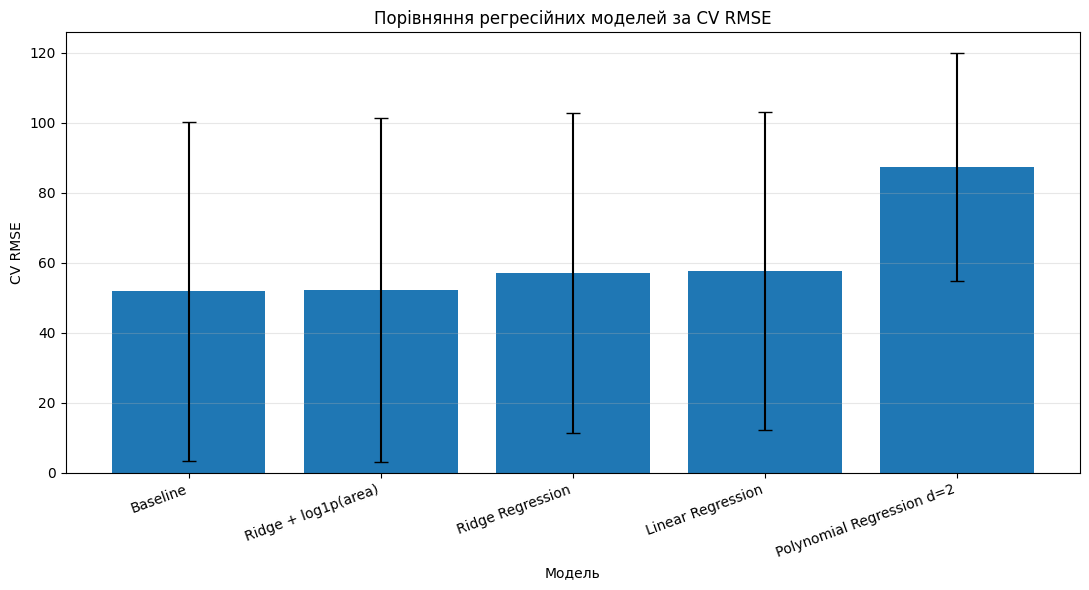

In [22]:
plt.figure(figsize=(11, 6))

plt.bar(
    results["Модель"],
    results["CV RMSE"],
    yerr=results["CV RMSE std"],
    capsize=5
)

plt.ylabel("CV RMSE")
plt.xlabel("Модель")
plt.title("Порівняння регресійних моделей за CV RMSE")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
stability = results.sort_values(
    by="CV RMSE std",
    ascending=True
)

print("Моделі за стабільністю:")
display(
    stability[
        ["Модель", "CV RMSE", "CV RMSE std"]
    ]
)

Моделі за стабільністю:


,Модель,CV RMSE,CV RMSE std
4,Polynomial Regression d=2,87.354549,32.467018
3,Linear Regression,57.603350,45.469282
2,Ridge Regression,57.084228,45.826301
0,Baseline,51.851827,48.461372
1,Ridge + log1p(area),52.239872,49.071210


In [24]:
linear_model.fit(X_train, y_train)
polynomial_model.fit(X_train, y_train)
ridge_grid.best_estimator_.fit(X_train, y_train)
ridge_log_grid.best_estimator_.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
y_pred_poly = polynomial_model.predict(X_test)
y_pred_ridge = ridge_grid.best_estimator_.predict(X_test)
y_pred_ridge_log = ridge_log_grid.best_estimator_.predict(X_test)

In [25]:
test_models = {
    "Baseline": y_pred_baseline,
    "Linear Regression": y_pred_linear,
    "Polynomial Regression d=2": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Ridge + log1p(area)": y_pred_ridge_log
}

test_results = []

for name, predictions in test_models.items():
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)
    r2 = r2_score(y_test, predictions)

    test_results.append({
        "Модель": name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    })

test_results = pd.DataFrame(test_results)

display(
    test_results.sort_values(
        by="Test RMSE",
        ascending=True
    ).reset_index(drop=True)
)

,Модель,Test MAE,Test RMSE,Test R2
0,Ridge + log1p(area),7.396079,20.092626,-0.048335
1,Ridge Regression,14.472557,20.610944,-0.103119
2,Baseline,14.518359,20.857056,-0.129621
3,Linear Regression,16.306604,22.200957,-0.279883
4,Polynomial Regression d=2,112.907134,192.817470,-95.542709


In [26]:
model_objects = {
    "Baseline": baseline,
    "Linear Regression": linear_model,
    "Polynomial Regression d=2": polynomial_model,
    "Ridge Regression": ridge_grid.best_estimator_,
    "Ridge + log1p(area)": ridge_log_grid.best_estimator_
}

predictions_objects = {
    "Baseline": y_pred_baseline,
    "Linear Regression": y_pred_linear,
    "Polynomial Regression d=2": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Ridge + log1p(area)": y_pred_ridge_log
}

final_model_name = results.iloc[1]["Модель"]
final_model = model_objects[final_model_name]
y_pred_final = predictions_objects[final_model_name]

print("Фінально обрана модель:")
print(final_model_name)

Фінально обрана модель:
Ridge + log1p(area)


In [27]:
final_mae = mean_absolute_error(
    y_test,
    y_pred_final
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_final
    )
)

final_r2 = r2_score(
    y_test,
    y_pred_final
)

print("ФІНАЛЬНА ОЦІНКА")
print("-" * 40)
print("Модель:", final_model_name)
print(f"MAE  = {final_mae:.4f}")
print(f"RMSE = {final_rmse:.4f}")
print(f"R2   = {final_r2:.4f}")

ФІНАЛЬНА ОЦІНКА
----------------------------------------
Модель: Ridge + log1p(area)
MAE  = 7.3961
RMSE = 20.0926
R2   = -0.0483


In [28]:
comparison_final = pd.DataFrame({
    "Модель": [
        "Baseline",
        final_model_name
    ],
    "MAE": [
        baseline_test_mae,
        final_mae
    ],
    "RMSE": [
        baseline_test_rmse,
        final_rmse
    ],
    "R2": [
        baseline_test_r2,
        final_r2
    ]
})

display(comparison_final)

,Модель,MAE,RMSE,R2
0,Baseline,14.518359,20.857056,-0.129621
1,Ridge + log1p(area),7.396079,20.092626,-0.048335


In [29]:
comparison_final = pd.DataFrame({
    "Модель": [
        "Baseline",
        final_model_name
    ],
    "MAE": [
        baseline_test_mae,
        final_mae
    ],
    "RMSE": [
        baseline_test_rmse,
        final_rmse
    ],
    "R2": [
        baseline_test_r2,
        final_r2
    ]
})

display(comparison_final)

,Модель,MAE,RMSE,R2
0,Baseline,14.518359,20.857056,-0.129621
1,Ridge + log1p(area),7.396079,20.092626,-0.048335


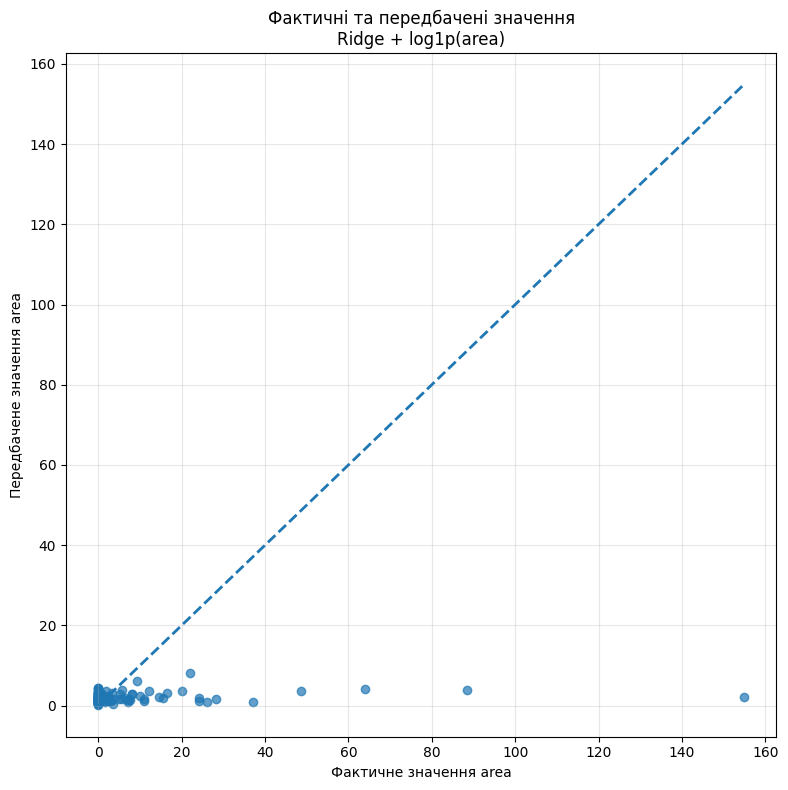

In [30]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_final,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    y_pred_final.min()
)

max_value = max(
    y_test.max(),
    y_pred_final.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Фактичне значення area")
plt.ylabel("Передбачене значення area")
plt.title(
    f"Фактичні та передбачені значення\n{final_model_name}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
print("Аналіз графіка y_true проти y_predicted")
print("-" * 50)

print(
    "Ідеальна модель розташовувала б усі точки "
    "на діагоналі y_predicted = y_true."
)

print(
    "Точки вище діагоналі означають завищення прогнозу, "
    "а точки нижче діагоналі — заниження прогнозу."
)

print(
    "Велика відстань точки від діагоналі відповідає "
    "великій абсолютній похибці."
)

Аналіз графіка y_true проти y_predicted
--------------------------------------------------
Ідеальна модель розташовувала б усі точки на діагоналі y_predicted = y_true.
Точки вище діагоналі означають завищення прогнозу, а точки нижче діагоналі — заниження прогнозу.
Велика відстань точки від діагоналі відповідає великій абсолютній похибці.


In [32]:
residuals = y_test - y_pred_final

residuals_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_final,
    "residual": residuals.values,
    "absolute_error": np.abs(residuals.values)
})

display(residuals_df.head())

,y_true,y_pred,residual,absolute_error
0,0.00,1.122430,-1.122430,1.122430
1,0.00,4.358826,-4.358826,4.358826
2,0.00,0.726401,-0.726401,0.726401
3,1.56,0.832362,0.727638,0.727638
4,0.00,3.215556,-3.215556,3.215556


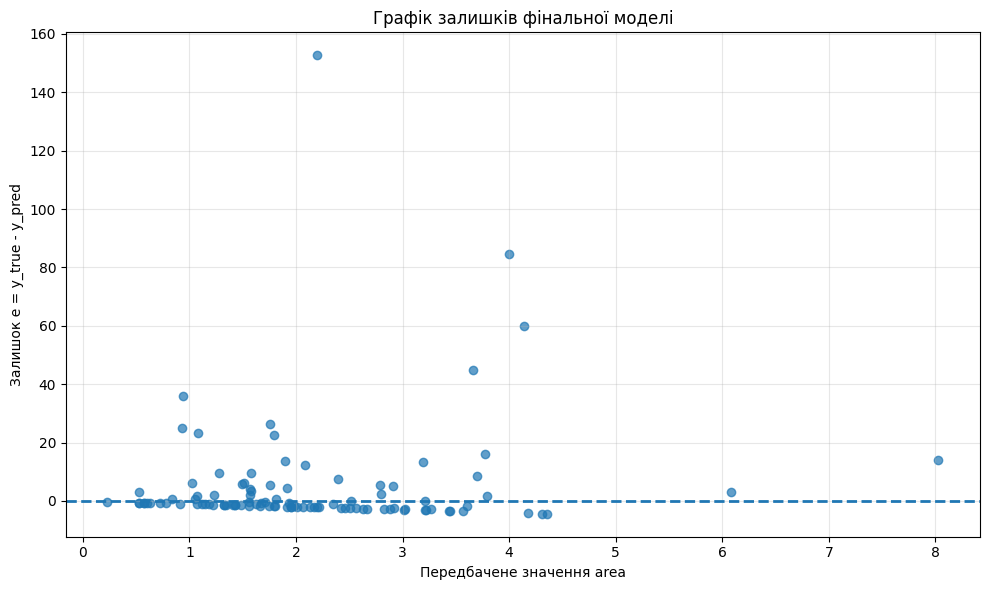

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_final,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Передбачене значення area")
plt.ylabel("Залишок e = y_true - y_pred")
plt.title("Графік залишків фінальної моделі")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
positive_residuals = residuals[residuals > 0]
negative_residuals = residuals[residuals < 0]

print("Кількість позитивних залишків:", len(positive_residuals))
print("Кількість негативних залишків:", len(negative_residuals))

print(
    f"Середній залишок: {residuals.mean():.4f}"
)

print(
    f"Медіана залишків: {residuals.median():.4f}"
)

print(
    f"Максимальний позитивний залишок: {residuals.max():.4f}"
)

print(
    f"Мінімальний залишок: {residuals.min():.4f}"
)

Кількість позитивних залишків: 38
Кількість негативних залишків: 65
Середній залишок: 5.1131
Медіана залишків: -0.8429
Максимальний позитивний залишок: 152.6810
Мінімальний залишок: -4.3588


In [35]:
mean_residual = residuals.mean()

if mean_residual > 0:
    print(
        "Середній залишок додатний: модель у середньому "
        "має тенденцію занижувати прогноз."
    )
elif mean_residual < 0:
    print(
        "Середній залишок від'ємний: модель у середньому "
        "має тенденцію завищувати прогноз."
    )
else:
    print(
        "Середній залишок близький до нуля: "
        "вираженого систематичного зміщення не виявлено."
    )

Середній залишок додатний: модель у середньому має тенденцію занижувати прогноз.


In [36]:
top_errors = residuals_df.sort_values(
    by="absolute_error",
    ascending=False
).head(5)

display(top_errors)

,y_true,y_pred,residual,absolute_error
81,154.88,2.199022,152.680978,152.680978
68,88.49,3.997213,84.492787,84.492787
37,64.10,4.142062,59.957938,59.957938
20,48.55,3.657836,44.892164,44.892164
95,37.02,0.939672,36.080328,36.080328


In [37]:
errors = np.abs(y_test - y_pred_final)

top_errors = errors.sort_values(ascending=False).head(5)

top_error_positions = np.argsort(-errors.to_numpy())[:5]

top_error_objects = X_test.iloc[top_error_positions].copy()

top_error_objects["actual_area"] = y_test.iloc[top_error_positions].values
top_error_objects["predicted_area"] = y_pred_final[top_error_positions]
top_error_objects["absolute_error"] = (
    np.abs(
        top_error_objects["actual_area"]
        - top_error_objects["predicted_area"]
    )
)

display(top_error_objects)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,actual_area,predicted_area,absolute_error
231,4,5,sep,sat,92.5,121.1,674.4,8.6,17.7,25,3.1,0.0,154.88,2.199022,152.680978
227,4,4,sep,wed,92.9,133.3,699.6,9.2,26.4,21,4.5,0.0,88.49,3.997213,84.492787
225,4,6,sep,sun,93.5,149.3,728.6,8.1,28.3,26,3.1,0.0,64.10,4.142062,59.957938
222,4,4,sep,sun,93.5,149.3,728.6,8.1,22.9,39,4.9,0.0,48.55,3.657836,44.892164
220,2,2,jul,fri,88.3,150.3,309.9,6.8,13.4,79,3.6,0.0,37.02,0.939672,36.080328


In [38]:
numeric_medians = X_train[numeric_features].median()

comparison = top_error_objects[numeric_features].copy()

for column in numeric_features:
    comparison[column + "_відносно_медіани"] = (
        comparison[column] - numeric_medians[column]
    )

display(comparison)

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,X_відносно_медіани,Y_відносно_медіани,FFMC_відносно_медіани,DMC_відносно_медіани,DC_відносно_медіани,ISI_відносно_медіани,temp_відносно_медіани,RH_відносно_медіани,wind_відносно_медіани,rain_відносно_медіани
231,4,5,92.5,121.1,674.4,8.6,17.7,25,3.1,0.0,0.0,1.0,0.9,12.7,9.9,0.2,-1.65,-17.0,-0.9,0.0
227,4,4,92.9,133.3,699.6,9.2,26.4,21,4.5,0.0,0.0,0.0,1.3,24.9,35.1,0.8,7.05,-21.0,0.5,0.0
225,4,6,93.5,149.3,728.6,8.1,28.3,26,3.1,0.0,0.0,2.0,1.9,40.9,64.1,-0.3,8.95,-16.0,-0.9,0.0
222,4,4,93.5,149.3,728.6,8.1,22.9,39,4.9,0.0,0.0,0.0,1.9,40.9,64.1,-0.3,3.55,-3.0,0.9,0.0
220,2,2,88.3,150.3,309.9,6.8,13.4,79,3.6,0.0,-2.0,-2.0,-3.3,41.9,-354.6,-1.6,-5.95,37.0,-0.4,0.0


In [39]:
print("=" * 60)
print("5 найбільших помилок")
print("=" * 60)

for idx, row in top_error_objects.iterrows():
    print(f"\nОб'єкт {idx}")
    print(f"Фактичне area:       {row['actual_area']:.4f}")
    print(f"Передбачене area:    {row['predicted_area']:.4f}")
    print(f"Абсолютна похибка:   {row['absolute_error']:.4f}")

5 найбільших помилок

Об'єкт 231
Фактичне area:       154.8800
Передбачене area:    2.1990
Абсолютна похибка:   152.6810

Об'єкт 227
Фактичне area:       88.4900
Передбачене area:    3.9972
Абсолютна похибка:   84.4928

Об'єкт 225
Фактичне area:       64.1000
Передбачене area:    4.1421
Абсолютна похибка:   59.9579

Об'єкт 222
Фактичне area:       48.5500
Передбачене area:    3.6578
Абсолютна похибка:   44.8922

Об'єкт 220
Фактичне area:       37.0200
Передбачене area:    0.9397
Абсолютна похибка:   36.0803


In [40]:
area_quantiles = y_train.quantile(
    [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

print("Квантілі area у навчальній вибірці:")
display(area_quantiles)

Квантілі area у навчальній вибірці:


0.25      0.0000
0.50      0.7150
0.75      6.5775
0.90     27.4810
0.95     50.7945
0.99    200.5386
Name: area, dtype: float64

In [41]:
top_error_actual_area = top_error_objects["actual_area"]

print("Фактичні area для 5 найбільших похибок:")

for value in top_error_actual_area:
    print(f"{value:.4f}")

print("\nМедіана area у train:", y_train.median())
print("Q3 area у train:", y_train.quantile(0.75))
print("Максимум area у train:", y_train.max())

Фактичні area для 5 найбільших похибок:
154.8800
88.4900
64.1000
48.5500
37.0200

Медіана area у train: 0.715
Q3 area у train: 6.577500000000001
Максимум area у train: 1090.84


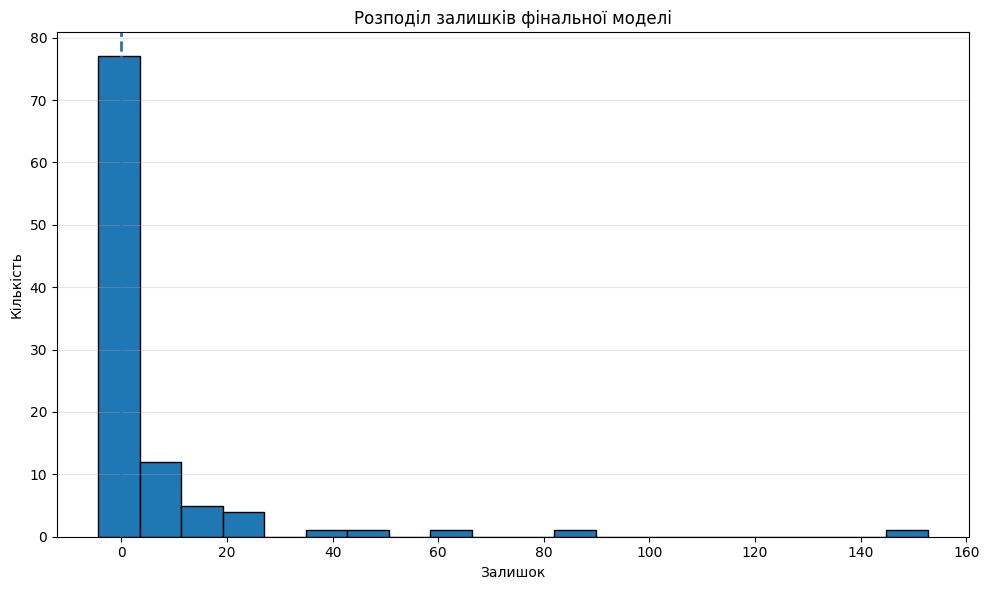

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Залишок")
plt.ylabel("Кількість")
plt.title("Розподіл залишків фінальної моделі")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
absolute_residuals = np.abs(residuals)

correlation_error_prediction = np.corrcoef(
    y_pred_final,
    absolute_residuals
)[0, 1]

print(
    "Кореляція між прогнозом та абсолютною похибкою:",
    round(correlation_error_prediction, 4)
)

if correlation_error_prediction > 0.5:
    print(
        "Спостерігається помітне збільшення абсолютної "
        "похибки зі зростанням прогнозованого значення."
    )
else:
    print(
        "Сильного лінійного зв'язку між величиною прогнозу "
        "та абсолютною похибкою не виявлено."
    )

Кореляція між прогнозом та абсолютною похибкою: 0.1709
Сильного лінійного зв'язку між величиною прогнозу та абсолютною похибкою не виявлено.


In [44]:
features_without_dc = [
    feature for feature in X.columns
    if feature != "DC"
]

preprocessor_without_dc = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            [
                f for f in numeric_features
                if f != "DC"
            ]
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

ridge_without_dc = Pipeline(
    steps=[
        ("preprocessor", preprocessor_without_dc),
        ("model", Ridge(alpha=ridge_grid.best_params_["model__alpha"]))
    ]
)

ridge_without_dc_cv = cross_validate(
    ridge_without_dc,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_without_dc_rmse = -ridge_without_dc_cv["test_score"]

print("Ridge без DC")
print("-" * 40)
print(f"CV RMSE: {ridge_without_dc_rmse.mean():.4f}")
print(f"CV RMSE std: {ridge_without_dc_rmse.std():.4f}")

print("\nRidge з DC")
print(f"CV RMSE: {ridge_rmse.mean():.4f}")
print(f"CV RMSE std: {ridge_rmse.std():.4f}")

Ridge без DC
----------------------------------------
CV RMSE: 52.0228
CV RMSE std: 48.3324

Ridge з DC
CV RMSE: 57.0842
CV RMSE std: 45.8263


In [45]:
numeric_only_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

preprocessor_without_categories = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_only_preprocessor,
            numeric_features
        )
    ],
    remainder="drop"
)

ridge_without_categories = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_without_categories
        ),
        (
            "model",
            Ridge(
                alpha=ridge_grid.best_params_["model__alpha"]
            )
        )
    ]
)

ridge_without_categories_cv = cross_validate(
    ridge_without_categories,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_without_categories_rmse = (
    -ridge_without_categories_cv["test_score"]
)

print("Ridge без month і day")
print("-" * 40)
print(
    f"CV RMSE: {ridge_without_categories_rmse.mean():.4f}"
)

print("\nRidge з month і day")
print(
    f"CV RMSE: {ridge_rmse.mean():.4f}"
)

Ridge без month і day
----------------------------------------
CV RMSE: 52.0205

Ridge з month і day
CV RMSE: 57.0842


In [46]:
final_report_table = results[
    [
        "Модель",
        "CV RMSE",
        "CV RMSE std",
        "CV MAE",
        "CV R2",
        "Параметри"
    ]
].copy()

final_report_table["CV RMSE"] = (
    final_report_table["CV RMSE"].round(4)
)

final_report_table["CV RMSE std"] = (
    final_report_table["CV RMSE std"].round(4)
)

final_report_table["CV MAE"] = (
    final_report_table["CV MAE"].round(4)
)

final_report_table["CV R2"] = (
    final_report_table["CV R2"].round(4)
)

display(final_report_table)

,Модель,CV RMSE,CV RMSE std,CV MAE,CV R2,Параметри
0,Baseline,51.8518,48.4614,20.9744,-0.0861,strategy=mean
1,Ridge + log1p(area),52.2399,49.0712,14.5439,-0.0762,alpha=1.0
2,Ridge Regression,57.0842,45.8263,25.8646,-0.6535,alpha=1000.0
3,Linear Regression,57.6034,45.4693,26.4238,-0.7380,—
4,Polynomial Regression d=2,87.3545,32.4670,48.2902,-6.6255,degree=2


In [47]:
print("=" * 70)
print("ПІДСУМКИ ЕКСПЕРИМЕНТУ")
print("=" * 70)

print(f"\nКількість об'єктів після очищення: {len(df_clean)}")
print(f"Кількість вхідних ознак: {X.shape[1]}")
print(f"Розмір train: {X_train.shape}")
print(f"Розмір test: {X_test.shape}")

print("\nНайкраща модель за CV RMSE:")
print(final_model_name)

print(f"CV RMSE: {results.iloc[0]['CV RMSE']:.4f}")
print(f"CV RMSE std: {results.iloc[0]['CV RMSE std']:.4f}")

print("\nФінальні тестові метрики:")
print(f"MAE:  {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"R2:   {final_r2:.4f}")

print("\nBaseline на тесті:")
print(f"MAE:  {baseline_test_mae:.4f}")
print(f"RMSE: {baseline_test_rmse:.4f}")
print(f"R2:   {baseline_test_r2:.4f}")

print("\nПорівняння з baseline:")

if final_rmse < baseline_test_rmse:
    print("Фінальна модель краща за baseline за RMSE.")
else:
    print("Фінальна модель не краща за baseline за RMSE.")

if final_mae < baseline_test_mae:
    print("Фінальна модель краща за baseline за MAE.")
else:
    print("Фінальна модель не краща за baseline за MAE.")

if final_r2 > baseline_test_r2:
    print("Фінальна модель краща за baseline за R².")
else:
    print("Фінальна модель не краща за baseline за R².")

ПІДСУМКИ ЕКСПЕРИМЕНТУ

Кількість об'єктів після очищення: 513
Кількість вхідних ознак: 12
Розмір train: (410, 12)
Розмір test: (103, 12)

Найкраща модель за CV RMSE:
Ridge + log1p(area)
CV RMSE: 51.8518
CV RMSE std: 48.4614

Фінальні тестові метрики:
MAE:  7.3961
RMSE: 20.0926
R2:   -0.0483

Baseline на тесті:
MAE:  14.5184
RMSE: 20.8571
R2:   -0.1296

Порівняння з baseline:
Фінальна модель краща за baseline за RMSE.
Фінальна модель краща за baseline за MAE.
Фінальна модель краща за baseline за R².
